# EPRdating quick start

From EPR spectra to an age with its Monte Carlo uncertainty. The data are
simulated, so the notebook runs anywhere (Jupyter, JupyterLab, Google Colab).
Replace the simulation cells by your files (`read_epr`, `analyse_files`).

## Install

In **Google Colab** (or any fresh environment) run the next cell once. In a local
Jupyter with EPRdating already installed, skip it.

In [1]:
%pip install "eprdating[plot] @ git+https://github.com/MiguelGamezL/EPRdating"

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import eprdating
from eprdating import (
    LinearUptake,
    Sediment,
    ToothLayers,
    ToothSample,
    cosmic_dose_rate,
    fit_dose_response,
    plot,
)
from eprdating.spectra import ComponentBasis, Spectrum, pseudo_modulation

print("EPRdating", eprdating.__version__)

EPRdating 0.1.0


## 1. A dose series of EPR spectra

With real data: `spectra = [read_epr(f) for f in files]` (Bruker `.DSC`/`.DTA`,
`.par`/`.spc`, ASCII or CSV). Here eight aliquots are simulated, with a
true De of 40 Gy.

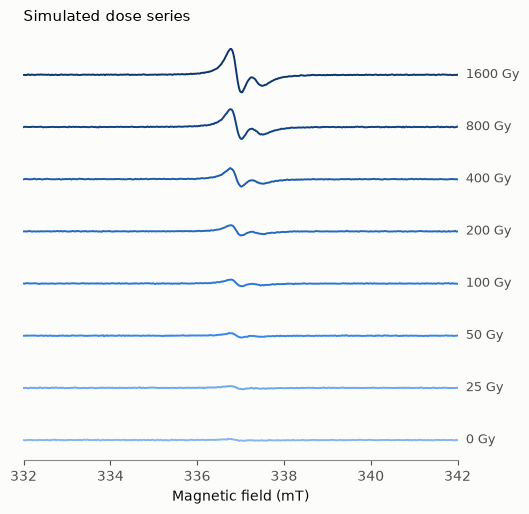

In [3]:
rng = np.random.default_rng(1)
B = np.linspace(332, 342, 400)                       # mT

def line(c, w):                                       # Lorentzian derivative
    x = (B - c) / (w * np.sqrt(3) / 2)
    return -x / (1 + x**2) ** 2

shape = line(336.9, 0.25) + 0.35 * line(337.35, 0.35)
shape = pseudo_modulation(B, shape / np.ptp(shape), 0.1)

doses = np.array([0, 25, 50, 100, 200, 400, 800, 1600])
spectra = []
for d in doses:
    amp = 100 * (1 - np.exp(-(d + 40) / 1200)) * rng.normal(1, 0.02)
    scans = amp * shape + 0.6 * rng.standard_normal((4, B.size))
    spectra.append(Spectrum(B, scans, name=f"{d} Gy"))

plot.plot_spectra(spectra, [f"{d} Gy" for d in doses], title="Simulated dose series");

## 2. Intensities and dose-response

A template fit gives each amplitude with its uncertainty.

Model SSE:  De = 36.85 ± 3.2
  Imax  = 94.12 ± 1.7
  D0    = 1164 ± 39
  chi2_red = 7.26, R² = 0.99984


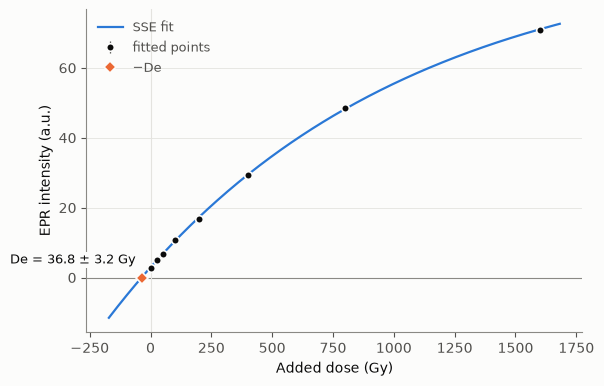

In [4]:
basis = ComponentBasis(B, {"CO2-": shape}, baseline_order=1)
fits = [basis.fit(s.y, nonnegative=False) for s in spectra]
amps = np.array([f.amplitudes["CO2-"] for f in fits])
errs = np.array([f.errors["CO2-"] for f in fits])

drc = fit_dose_response(doses, amps, "SSE", sigma=errs)
print(drc.summary())
plot.plot_dose_response(drc);

## 3. Age

With measured sediment: `sediment = analyse_files(...).sediment(water=...)`
(see the user guide).

Age = 29.97 ka   (De = 36.85 Gy, <Ḋ> = 1.229 Gy/ka)
  enamel alpha     Ḋ_now =   0.2180 Gy/ka   contributes   2.4 % of De
  enamel beta      Ḋ_now =   0.0649 Gy/ka   contributes   1.1 % of De
  dentine beta     Ḋ_now =   0.2097 Gy/ka   contributes   4.8 % of De
  sediment beta    Ḋ_now =   0.1515 Gy/ka   contributes  12.3 % of De
  gamma            Ḋ_now =   0.7322 Gy/ka   contributes  59.6 % of De
  cosmic           Ḋ_now =   0.2436 Gy/ka   contributes  19.8 % of De


Age (nominal) = 29.97 ka
MC: mean = 29.83 ± 2.9 ka (68 %: 26.96–32.68; 95 %: 24.43–35.78; n = 1000)


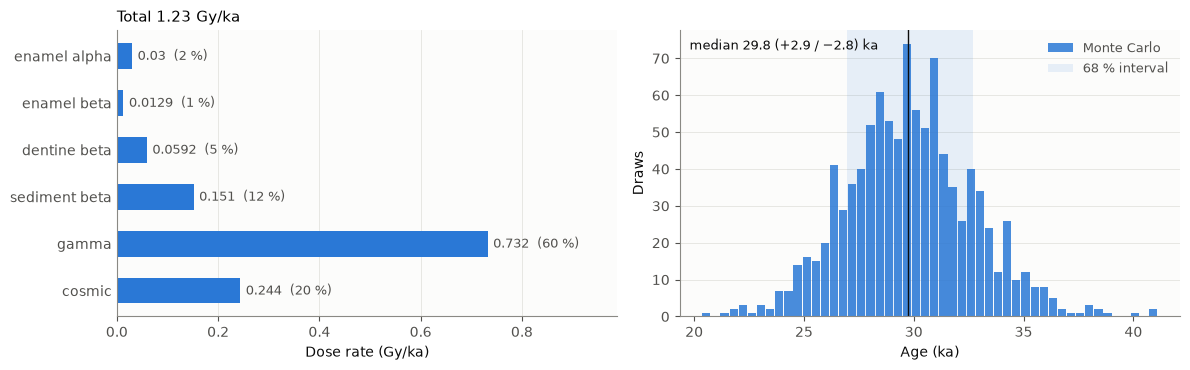

In [5]:
tooth = ToothSample(
    De=(drc.De, drc.De_sigma),
    enamel_U=(0.6, 0.06), dentine_U=(12.0, 1.2),
    sediment=Sediment(U=(2.0, 0.1), Th=(7.0, 0.3), K=(1.2, 0.05), water=(0.15, 0.05)),
    beta=ToothLayers(enamel_um=(1100, 100), strip_outer_um=(50, 20), strip_inner_um=(50, 20)),
    cosmic=cosmic_dose_rate(depth_m=1.5, density=1.9, lat_deg=4.6, lon_deg=-74.1, altitude_m=2600),
    uptake_enamel=LinearUptake(), uptake_dentine=LinearUptake(),
)
result = tooth.age()
print(result.summary())
mc = tooth.age_mc(n=1000, seed=2)
print(mc.summary())

fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.8))
plot.plot_dose_rate(result, ax=a)
plot.plot_age_distribution(mc, ax=b)
fig.tight_layout()

More: [user guide](https://github.com/MiguelGamezL/EPRdating/blob/main/docs/guide.md) ·
[figures](https://github.com/MiguelGamezL/EPRdating/blob/main/docs/plotting.md) ·
[API reference](https://github.com/MiguelGamezL/EPRdating/blob/main/docs/api/index.md)